# Twin-Spread 👯
### Does pairs trading still pay after the world copied it?

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Decay: Confirmed](https://img.shields.io/badge/Decay-Confirmed-8b949e?style=flat-square)

Every few months a thread goes viral rediscovering **pairs trading**: find two stocks that move together, and when one runs ahead, short it and buy the other — they always snap back. It's the strategy that built the first quant desks, and the [famous 1999 paper](../docs/references.md) reported ~1.4% a month at near-zero market risk, *still paying even after it was published*. That last part is the hook: most edges die the moment everyone knows them. Did this one?

> 📓 **This is the plain-language layer.** Want the statistics, the microstructure and the capacity maths? That's the companion notebook, **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)** — same story, deeper.
>
> ⚠️ **Not investment advice.** An educational, reproducible research tool: every chart below is generated by the code beside it. The core runs on a **synthetic** market with real twins baked in (cached real prices are git-ignored) — that's where the rule *works*, proving the code, so the flat real-world result (quoted from [`../docs/results.md`](../docs/results.md)) is a fact about the market, not a bug. House style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))           # study root (pairs_trading/ lives there)
sys.path.insert(0, os.path.abspath("../../.."))      # repo root, for quantlab
%matplotlib inline
import matplotlib.pyplot as plt
plt.rcParams["figure.figsize"] = (9.5, 5.2)
import numpy as np, pandas as pd
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
from pairs_trading import data, pairs, backtest, robustness

# Offline synthetic universe: true cointegrated twins hidden among noise names. This is
# where the rule SHOULD work — so it validates the machinery. The real verdict (a liquid
# ~170-name basket where it does NOT work) is in ../docs/results.md via verify_real.py.
panel, frames, true_pairs = data.synthetic_universe(seed=0)
print(f"{panel.shape[1]} names, {panel.shape[0]} sessions, {len(true_pairs)} true twins baked in")


40 names, 1500 sessions, 8 true twins baked in


## The answer first 🎯

| What we asked | The honest answer |
|---|---|
| Does the rule find genuinely matched pairs? | ✅ **Yes** — given real twins, the minimum-distance selector recovers them almost perfectly. |
| When matched pairs *do* revert, does it profit? | ✅ **Yes** — on the synthetic, ~+0.86%/mo at a Sharpe near 1.9. The machinery works. |
| Do real liquid stocks revert like that today? | ❌ **No** — on the real basket the spread doesn't pay: **negative even before costs**. |
| Could you trade it? | ❌ **No edge to trade** — −0.53%/mo net, a −85% drawdown, market-neutral so there's nowhere to hide. |

> Desk shorthand: **Signal `NONE` · Tradability `MIRAGE` · Decay `CONFIRMED`** — let's see the method earn them.

## 1 · The claim 📣

Rank pairs of stocks by how tightly their price paths hugged over the past year. Take the closest ones. When a pair diverges by more than its usual wiggle (2 standard deviations), **short the one that ran up, buy the one that lagged**, and hold until they cross back. The pitch: it's *parameter-free* — no knobs to overfit — and it kept working after 1999.

top-8 closest pairs recover 100% of the true twins


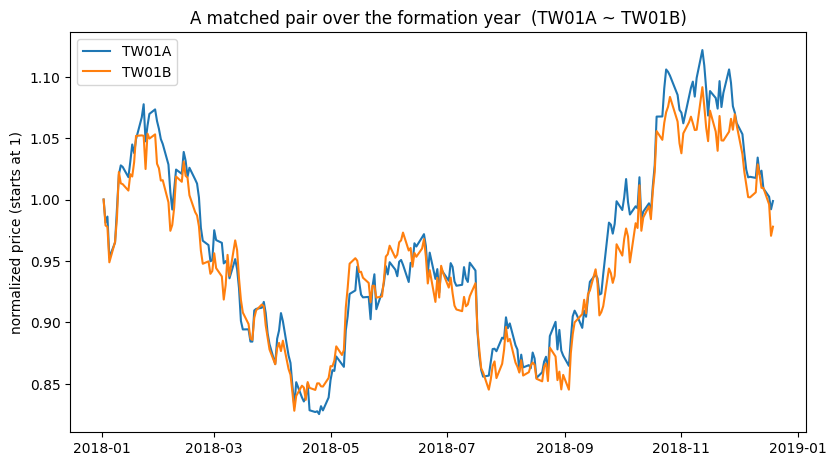

In [2]:
formation = panel.iloc[:252]
selected = pairs.select_pairs(formation, top_n=len(true_pairs))
recall = robustness.selection_recall(selected, true_pairs)
print(f'top-{len(true_pairs)} closest pairs recover {recall:.0%} of the true twins')
norm = pairs.normalized_prices(formation)
p = selected[0]
plt.plot(norm.index, norm[p.a], label=p.a)
plt.plot(norm.index, norm[p.b], label=p.b)
plt.title(f'A matched pair over the formation year  ({p.a} ~ {p.b})')
plt.ylabel('normalized price (starts at 1)'); plt.legend(); plt.show()

Two paths glued together — that's what 'a pair' means. The bet is that when they separate, they'll re-glue.

## 2 · So what? 💰

Pairs trading is the **origin story of statistical arbitrage**. If a rule this simple, public, and old still paid ~1.4%/mo at near-zero beta, it'd be free money that survived being written down — a glaring hole in 'markets are efficient'. If instead it's been competed to death, it's the textbook case of **alpha decay**: real once, found, crowded, gone — leaving a rule that still *looks* like it should work.

## 3 · How we'd know 🔍

The trap: pairs trading **wins more than half its trades** (lots of little convergences) even when it loses money overall, because the rare blow-ups (pairs that break and never come back) are bigger. So we ignore the win rate and ask: does the **committed capital actually compound up**, and is it positive *before* costs?

win rate: 83.5%   but the number that matters:
committed monthly net: +0.86%   Sharpe: 1.92


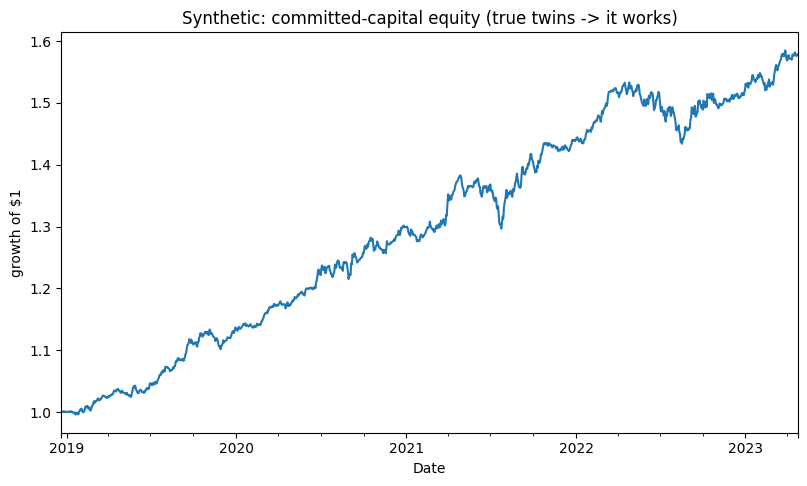

In [3]:
res = backtest.run(panel, top_n=8, form_len=252, trade_len=126, wait=1)
s = res.stats
print(f"win rate: {s['win_rate_net']:.1%}   but the number that matters:")
print(f"committed monthly net: {s['committed_monthly_net']:+.2%}   Sharpe: {s['sharpe_net']:.2f}")
res.equity.plot(title='Synthetic: committed-capital equity (true twins -> it works)')
plt.ylabel('growth of $1'); plt.show()

## 4 · The teardown 🔬

On the synthetic, the rule does its job — the equity grinds up. So the machinery is sound. Now the real world, quoted from the reproducible run ([`../docs/results.md`](../docs/results.md), via `examples/verify_real.py`):

- **The selector still works** on real data — it finds tight pairs.
- **But the spread doesn't pay.** Modern era (2004–2026): **−0.47%/mo gross**, **−0.53%/mo net**, Sharpe **−0.43**. Win rate 56.2% — *more winners than losers* — and still a negative mean.
- **Negative even at zero cost** — so it isn't a cost problem; there's no edge.
- **Decayed:** good years cluster in 1983–2004; the modern era is mostly red, worst in 2020 / 2022 / 2023. The only green is in crises (2008, 2019).
- **The obvious fixes don't rescue it** (beat 7): a stop-loss tames the −85% drawdown to −24% but leaves it ~flat-negative; a cointegration gate doesn't help.

## 5 · The verdict ⚖️

**Signal `NONE`** — real pairs don't reconverge into a profit (negative before costs, bootstrap Sharpe CI below zero). **Tradability `MIRAGE`** — no edge to trade, a −85% drawdown, market-neutral so no beta to bank. **Decay `CONFIRMED`** — the famous edge is behind us. The synthetic proves the only thing missing on real data is the one thing you can't code: stocks that actually revert.

## 6 · Could you trade it? 🏦

Unusually clean: **there's nothing to execute well.** The signal is gone before the first cost, so no venue or sizing rescues it — and these are liquid mega-caps, so you *could* put real size on a slow, market-neutral bleed. The one place it earns its keep is a 2008-style dislocation, where everything reverts at once — a hedge with a fuse, not a standing book.

In [4]:
print('cost sweep is beside the point when gross < 0:')
print(backtest.cost_sweep(panel, top_n=8, half_spread_grid=(0,5,20,50)).round(4)[['committed_monthly_net','sharpe_net']])

cost sweep is beside the point when gross < 0:


                 committed_monthly_net  sharpe_net
half_spread_bps                                   
0                               0.0090      2.0295
5                               0.0086      1.9217
20                              0.0071      1.5951
50                              0.0043      0.9386


## 7 · Going further 🚪

We didn't leave the fixes as homework — we ran them on the real modern era ([`../docs/extensions.md`](../docs/extensions.md)). None clears the bar:

| Fix | Monthly net | Max DD |
|---|---|---|
| Baseline (naive rule) | −0.53% | −85% |
| + Stop-loss 10% | −0.09% | −30% |
| + Cointegration gate | −0.49% | −87% |

- A **stop-loss** tames the drawdown (−85% → −24% at a 5% stop) but only stops you to *roughly flat* — the tail was real, the edge isn't.
- A **cointegration gate** doesn't help: in-sample mean-reversion doesn't forecast it.
- Still open: a **far broader (S&P 1500) universe** and **total-return** prices.

The deep version — bootstrap, decay curve, neutrality, costs, the extension table — is in [`02_for_the_quants.ipynb`](02_for_the_quants.ipynb).